Question 1 - Simulating Instructions

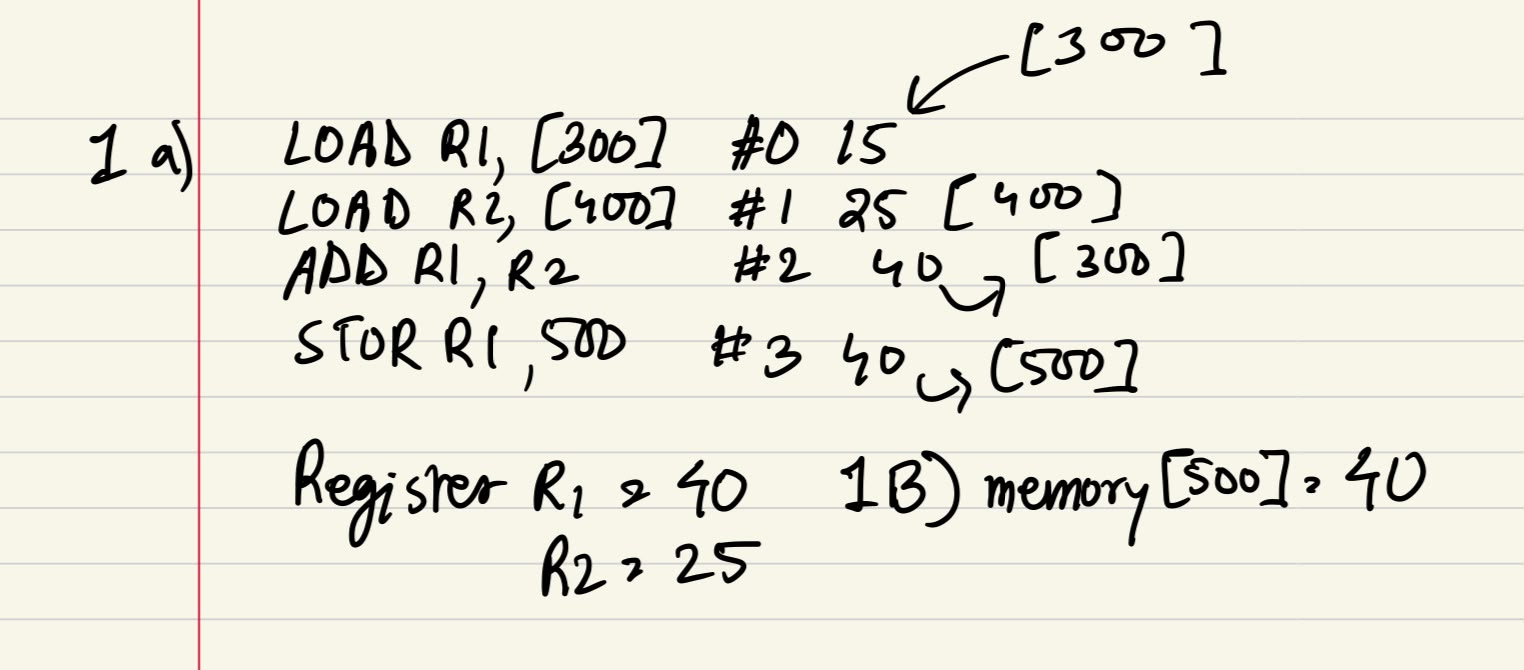

In [1]:
memory = {300: 15, 400: 25}
registers = {"R1": 0, "R2": 0}

program = [
    "LOAD R1, [300]",
    "LOAD R2, [400]",
    "ADD R1, R2",
    "STORE R1, [500]"
]

pc = 0

while pc < len(program):
    instr = program[pc]

    if instr.startswith("LOAD"):
        parts = instr.split()
        reg = parts[1].strip(",")
        addr = int(parts[2][1:-1])
        registers[reg] = memory[addr]
        print(f"[{pc}] LOAD {reg}, [{addr}]  →  {reg} = {registers[reg]}")
        pc += 1

    elif instr.startswith("ADD"):
        parts = instr.split()
        reg1 = parts[1].strip(",")
        reg2 = parts[2]
        registers[reg1] += registers[reg2]
        print(f"[{pc}] ADD {reg1}, {reg2}  →  {reg1} = {registers[reg1]}")
        pc += 1

    elif instr.startswith("STORE"):
        parts = instr.split()
        reg = parts[1].strip(",")
        addr = int(parts[2][1:-1])
        memory[addr] = registers[reg]
        print(f"[{pc}] STORE {reg}, [{addr}]  →  Memory[{addr}] = {registers[reg]}")
        pc += 1

print("\nFINAL STATE:")
print(f"Registers: {registers}")
print(f"Memory: {memory}")

[0] LOAD R1, [300]  →  R1 = 15
[1] LOAD R2, [400]  →  R2 = 25
[2] ADD R1, R2  →  R1 = 40
[3] STORE R1, [500]  →  Memory[500] = 40

FINAL STATE:
Registers: {'R1': 40, 'R2': 25}
Memory: {300: 15, 400: 25, 500: 40}


Question 2 - Control Flow Simulation

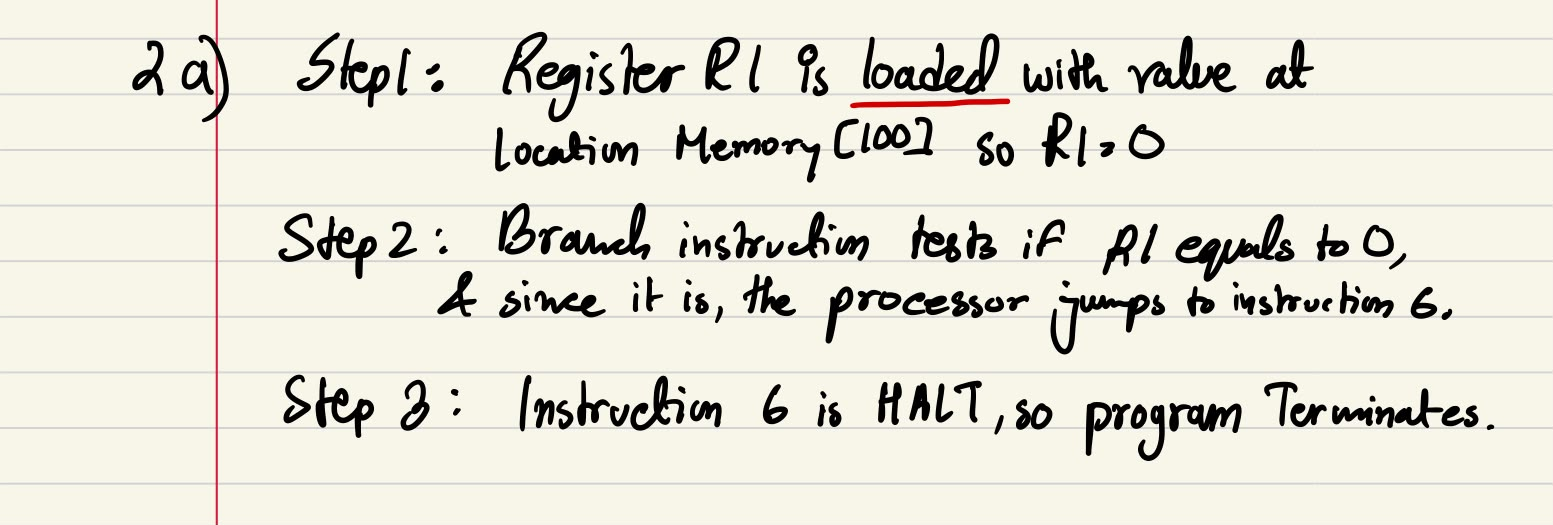

In [6]:

memory = {100: 0}
registers = {"R1": 0, "R2": 3}

program = [
    "LOAD R1, [100]",
    "BRANCH R1 == 0, 6",
    "SUB R1, R2",
    "JUMP 7",
    "ADD R1, R2",
    "HALT",
    "HALT",
]

pc = 0

print("EXECUTING PROGRAM:")

while pc < len(program):
    instr = program[pc]

    if instr.startswith("LOAD"):
        parts = instr.split()
        reg = parts[1].strip(",")
        addr = int(parts[2][1:-1])
        registers[reg] = memory[addr]
        print(f"[{pc}] LOAD {reg}, [{addr}]  →  {reg} = {registers[reg]}")
        pc += 1

    elif instr.startswith("BRANCH"):
        parts = instr.split()
        reg, op, val, target = parts[1], parts[2], int(parts[3].strip(",")), int(parts[4])
        cond = (registers[reg] == val) if op == "==" else (registers[reg] != val)
        if cond:
            print(f"[{pc}] BRANCH {reg} {op} {val}  →  TRUE, jump to {target}")
            pc = target
        else:
            print(f"[{pc}] BRANCH {reg} {op} {val}  →  FALSE")
            pc += 1

    elif instr.startswith("JUMP"):
        target = int(instr.split()[1])
        print(f"[{pc}] JUMP {target}")
        pc = target

    elif instr.startswith("SUB"):
        reg1, reg2 = instr.split()[1].strip(","), instr.split()[2]
        old = registers[reg1]
        registers[reg1] -= registers[reg2]
        print(f"[{pc}] SUB {reg1}, {reg2}  →  {reg1} = {old} - {registers[reg2]} = {registers[reg1]}")
        pc += 1

    elif instr.startswith("ADD"):
        reg1, reg2 = instr.split()[1].strip(","), instr.split()[2]
        old = registers[reg1]
        registers[reg1] += registers[reg2]
        print(f"[{pc}] ADD {reg1}, {reg2}  →  {reg1} = {old} + {registers[reg2]} = {registers[reg1]}")
        pc += 1

    elif instr == "HALT":
        print(f"[{pc}] HALT")
        break

print(f"Final: R1 = {registers['R1']}, R2 = {registers['R2']}")

EXECUTING PROGRAM:
[0] LOAD R1, [100]  →  R1 = 0
[1] BRANCH R1 == 0  →  TRUE, jump to 6
[6] HALT


Question 3 - Input/Output Simulation

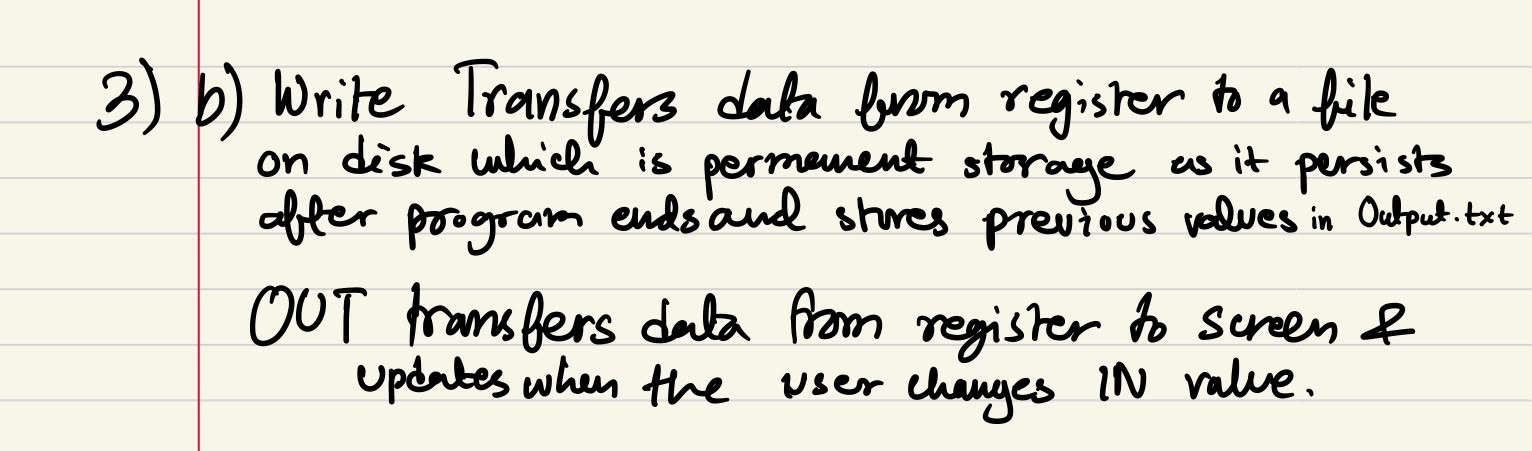

In [18]:
registers = {"R1": 0}

program = [
    "IN R1",
    "ADD R1, 10",
    "WRITE R1, output.txt",
    "OUT R1",
    "HALT"
]

pc = 0

while pc < len(program):
    instr = program[pc]

    if instr.startswith("IN"):
        parts = instr.split()
        reg = parts[1].strip(",")
        user_input = input(f"[{pc}] IN {reg} → Enter a number: ")
        registers[reg] = int(user_input)
        print(f"[{pc}] IN {reg}  →  {reg} = {registers[reg]}")
        pc += 1


    elif instr.startswith("ADD"):
        parts = instr.split()
        reg = parts[1].strip(",")
        value = int(parts[2].strip(","))
        old_value = registers[reg]
        registers[reg] += value
        print(f"[{pc}] ADD {reg}, {value}  →  {reg} = {old_value} + {value} = {registers[reg]}")
        pc += 1


    elif instr.startswith("WRITE"):
        parts = instr.split()
        reg = parts[1].strip(",")
        filename = parts[2]
        with open(filename, "a") as f:
            f.write(str(registers[reg]) + "\n")
        print(f"[{pc}] WRITE {reg}, {filename}  →  Saved {registers[reg]} to {filename}")
        pc += 1

    elif instr.startswith("OUT"):
        parts = instr.split()
        reg = parts[1].strip(",")
        print(f"[{pc}] OUT {reg}  →  OUTPUT: {registers[reg]}")
        pc += 1

    elif instr == "HALT":
        print(f"[{pc}] HALT  →  Program terminated")
        break

print(f"Final: R1 = {registers['R1']}")

[0] IN R1 → Enter a number: 8
[0] IN R1  →  R1 = 8
[1] ADD R1, 10  →  R1 = 8 + 10 = 18
[2] WRITE R1, output.txt  →  Saved 18 to output.txt
[3] OUT R1  →  OUTPUT: 18
[4] HALT  →  Program terminated
Final: R1 = 18
